## **African Cup of Nations 2023 Analysis**

## **1. Loading the Dataset**

In [1]:
%pip install statsbombpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import required libraries for AFCON analysis
import os
import pandas as pd
from statsbombpy import sb

# Optional: display nicer tabular output in notebooks
pd.options.display.max_columns = None
pd.options.display.width = 120

In [3]:
# running this code will print out a table of all competitions available in the StatsBomb dataset, including their IDs

from statsbombpy import sb
comps = sb.competitions()
print(comps[['competition_id','season_id','competition_name','season_name','competition_gender']])

/workspaces/Football_Data_Analysis_HQ/.venv/lib/python3.12/site-packages/statsbombpy/api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


    competition_id  season_id        competition_name season_name competition_gender
0                9        281           1. Bundesliga   2023/2024               male
1                9         27           1. Bundesliga   2015/2016               male
2             1267        107  African Cup of Nations        2023               male
3               16          4        Champions League   2018/2019               male
4               16          1        Champions League   2017/2018               male
..             ...        ...                     ...         ...                ...
75              35         75      UEFA Europa League   1988/1989               male
76              53        315       UEFA Women's Euro        2025             female
77              53        106       UEFA Women's Euro        2022             female
78              72        107       Women's World Cup        2023             female
79              72         30       Women's World Cup        2019

In [4]:
# Pull African Cup of Nations (AFCON) 2023 matches and events
# Assumes `comps` and `sb` are already defined (run previous cell first)

# Find AFCON competition/season row
afcon = comps[comps['competition_name'].str.contains('African Cup of Nations', case=False, na=False)]
print(afcon[['competition_id','season_id','competition_name','season_name']])
if afcon.empty:
    raise ValueError('African Cup of Nations not found in competitions list')

comp_id = int(afcon.iloc[0]['competition_id'])
season_id = int(afcon.iloc[0]['season_id'])

# Download matches for the competition/season
matches = sb.matches(competition_id=comp_id, season_id=season_id)
print(f'Found {len(matches)} matches for competition_id={comp_id}, season_id={season_id}')
matches.to_csv('afcon_matches_2023.csv', index=False)

# Create folder and download events for each match (may take time)
import os
os.makedirs('afcon_events', exist_ok=True)

for mid in matches['match_id']:
    try:
        events = sb.events(match_id=int(mid))
        # some sb.events returns a DataFrame-like object; try to save as CSV
        events.to_csv(os.path.join('afcon_events', f'events_{mid}.csv'), index=False)
    except Exception as e:
        print(f'Failed to fetch events for match {mid}: {e}')

   competition_id  season_id        competition_name season_name
2            1267        107  African Cup of Nations        2023


/workspaces/Football_Data_Analysis_HQ/.venv/lib/python3.12/site-packages/statsbombpy/api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Found 52 matches for competition_id=1267, season_id=107


/workspaces/Football_Data_Analysis_HQ/.venv/lib/python3.12/site-packages/statsbombpy/api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/workspaces/Football_Data_Analysis_HQ/.venv/lib/python3.12/site-packages/statsbombpy/api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/workspaces/Football_Data_Analysis_HQ/.venv/lib/python3.12/site-packages/statsbombpy/api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/workspaces/Football_Data_Analysis_HQ/.venv/lib/python3.12/site-packages/statsbombpy/api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/workspaces/Football_Data_Analysis_HQ/.venv/lib/python3.12/site-packages/statsbombpy/api_client.py:27: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/workspaces/Football_Data_Analysis_HQ/.venv/lib/python3.12/s

In [5]:
# Clean AFCON preview: shape, columns, dtypes, and first few rows only
print('AFCON matches shape:', matches.shape)
print('Columns:', list(matches.columns))
print('\nDtypes:')
print(matches.dtypes)
print('\nFirst few rows:')
matches.head()

AFCON matches shape: (52, 55)
Columns: ['match_id', 'match_date', 'kick_off', 'home_score', 'away_score', 'match_status', 'match_status_360', 'last_updated', 'last_updated_360', 'match_week', 'competition_id', 'competition_country_name', 'competition_name', 'competition', 'season_id', 'season', 'home_team_id', 'home_team', 'home_team_gender', 'home_team_group', 'home_team_country_id', 'home_team_country_name', 'away_team_id', 'away_team', 'away_team_gender', 'away_team_group', 'away_team_country_id', 'away_team_country_name', 'competition_stage_id', 'competition_stage', 'stadium_id', 'stadium', 'stadium_country_id', 'stadium_country_name', 'referee_id', 'referee', 'referee_country_id', 'referee_country_name', 'home_managers', 'away_managers', 'home_manager_id', 'home_manager_name', 'home_manager_nickname', 'home_manager_dob', 'home_manager_country_id', 'home_manager_country_name', 'away_manager_id', 'away_manager_name', 'away_manager_nickname', 'away_manager_dob', 'away_manager_country

,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version
0,3922240,2024-01-28,20:00:00.000,1,1,available,unscheduled,2026-05-02T14:23:45.490823,NaN,4,1267,Africa,African Cup of Nations,Africa - African Cup of Nations,107,2023,774,Egypt,male,None,66,Egypt,4881,Congo DR,male,None,52,"Congo, (Kinshasa)",33,Round of 16,1001497,Stade Laurent Pokou,55,Côte d'Ivoire,2323,Abongile Tom,211,South Africa,Rui Carlos Pinho da Vitória,Sébastien Desabre,261,Rui Carlos Pinho da Vitória,Rui Vitória,1970-04-16,183,Portugal,5011,Sébastien Desabre,NaN,1976-08-02,78,France,1.1.0,2,2
1,3920399,2024-01-19,14:00:00.000,3,0,available,unscheduled,2026-05-02T05:59:06.800066,NaN,2,1267,Africa,African Cup of Nations,Africa - African Cup of Nations,107,2023,4924,Cape Verde Islands,male,None,41,Cape Verde,4978,Mozambique,male,None,155,Mozambique,10,Group Stage,117916,Stade Félix Houphouët-Boigny,55,Côte d'Ivoire,1003709,Samir Guezzaz,154,Morocco,Pedro Leitão Brito,Francisco Queriol Conde Júnior,1000417,Pedro Leitão Brito,Bubista,1970-01-06,41,Cape Verde,1001646,Francisco Queriol Conde Júnior,Chiquinho Conde,1965-11-22,155,Mozambique,1.1.0,2,2
2,3920413,2024-01-23,17:00:00.000,2,3,available,unscheduled,2026-05-02T05:58:38.856282,NaN,3,1267,Africa,African Cup of Nations,Africa - African Cup of Nations,107,2023,4934,Gambia,male,None,83,Gambia,2722,Cameroon,male,None,39,Cameroon,10,Group Stage,1001316,Stade de Bouaké,55,Côte d'Ivoire,1000963,Bamlak Tessema Weyesa,72,Ethiopia,Tom Saintfiet,Rigobert Song Bahanag,1000972,Tom Saintfiet,NaN,1973-03-29,22,Belgium,1001250,Rigobert Song Bahanag,NaN,1976-07-01,39,Cameroon,1.1.0,2,2
3,3920400,2024-01-19,17:00:00.000,3,1,available,unscheduled,2026-05-02T05:58:12.096660,NaN,2,1267,Africa,African Cup of Nations,Africa - African Cup of Nations,107,2023,787,Senegal,male,None,202,Senegal,2722,Cameroon,male,None,39,Cameroon,10,Group Stage,1000822,Stade Charles Konan Banny de Yamoussoukro,55,Côte d'Ivoire,1003531,Mahmood Ali Mahmood Ismail,216,Sudan,Aliou Cissé,Rigobert Song Bahanag,635,Aliou Cissé,NaN,1976-03-24,202,Senegal,1001250,Rigobert Song Bahanag,NaN,1976-07-01,39,Cameroon,1.1.0,2,2
4,3920409,2024-01-22,17:00:00.000,0,1,available,unscheduled,2026-05-02T05:57:00.296561,NaN,3,1267,Africa,African Cup of Nations,Africa - African Cup of Nations,107,2023,4894,Guinea-Bissau,male,None,96,Guinea-Bissau,775,Nigeria,male,None,166,Nigeria,10,Group Stage,117916,Stade Félix Houphouët-Boigny,55,Côte d'Ivoire,1005493,Bouchra Karboubi,154,Morocco,Baciro Candé,José Vítor dos Santos Peseiro,1000429,Baciro Candé,NaN,1967-04-06,96,Guinea-Bissau,523,José Vítor dos Santos Peseiro,José Peseiro,1960-04-04,183,Portugal,1.1.0,2,2


In [6]:
# Check for missing values in each column
print('Missing values per column:')
missing_counts = matches.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "No missing values found!")
print(f'\nTotal missing values: {matches.isnull().sum().sum()}')

Missing values per column:
last_updated_360         51
home_team_group          52
away_team_group          52
home_manager_nickname    33
home_manager_dob          2
away_manager_nickname    42
away_manager_dob          1
dtype: int64

Total missing values: 233


In [7]:
# Check for duplicate rows
print('Duplicate rows:', matches.duplicated().sum())

if matches.duplicated().sum() > 0:
    print('\nDuplicate records:')
    display(matches[matches.duplicated(keep=False)].sort_values(by=list(matches.columns)))
else:
    print('No duplicate rows found!')

Duplicate rows: 0
No duplicate rows found!


In [8]:
# Validate key fields before cleaning
parsed_dates = pd.to_datetime(matches['match_date'], errors='coerce')

print('Unique match IDs:', matches['match_id'].is_unique)
print('Invalid match dates:', parsed_dates.isna().sum())
print('Negative scores:', ((matches['home_score'] < 0) | (matches['away_score'] < 0)).sum())
print('Competition IDs:', matches['competition_id'].unique())
print('Season IDs:', matches['season_id'].unique())
print('Match date range:', parsed_dates.min().date(), 'to', parsed_dates.max().date())
print('Number of matches:', len(matches))

Unique match IDs: True
Invalid match dates: 0
Negative scores: 0
Competition IDs: [1267]
Season IDs: [107]
Match date range: 2024-01-13 to 2024-02-11
Number of matches: 52


## **2. Data Cleaning and Manipulation**

In [9]:
# Create a working copy so the original dataset remains unchanged
matches_clean = matches.copy()

print('Working copy created:', matches_clean.shape)


Working copy created: (52, 55)


In [10]:
# Convert dates, times, scores, and identifiers to analysis-friendly types
matches_clean['match_date'] = pd.to_datetime(matches_clean['match_date'], errors='coerce')
matches_clean['kick_off'] = pd.to_timedelta(matches_clean['kick_off'], errors='coerce')

numeric_columns = [
    'match_id', 'home_score', 'away_score', 'match_week',
    'competition_id', 'season_id', 'home_team_id', 'away_team_id'
]
for column in numeric_columns:
    matches_clean[column] = pd.to_numeric(matches_clean[column], errors='coerce').astype('Int64')

# Remove accidental whitespace from text fields while preserving missing values
text_columns = matches_clean.columns[matches_clean.dtypes == 'object']
for column in text_columns:
    matches_clean[column] = matches_clean[column].str.strip()

print('Date dtype:', matches_clean['match_date'].dtype)
print('Kick-off dtype:', matches_clean['kick_off'].dtype)
print('Invalid dates:', matches_clean['match_date'].isna().sum())
print('Invalid kick-off values:', matches_clean['kick_off'].isna().sum())

Date dtype: datetime64[us]
Kick-off dtype: timedelta64[us]
Invalid dates: 0
Invalid kick-off values: 0


In [11]:
# Add match-level outcome and goal statistics
matches_clean['result'] = 'Draw'
matches_clean.loc[
    matches_clean['home_score'] > matches_clean['away_score'], 'result'
] = 'Home Win'
matches_clean.loc[
    matches_clean['home_score'] < matches_clean['away_score'], 'result'
] = 'Away Win'

matches_clean['total_goals'] = matches_clean['home_score'] + matches_clean['away_score']
matches_clean['goal_difference'] = matches_clean['home_score'] - matches_clean['away_score']
matches_clean['both_teams_scored'] = (
    (matches_clean['home_score'] > 0) & (matches_clean['away_score'] > 0)
)

print(matches_clean[['home_team', 'away_team', 'home_score', 'away_score', 'result', 'total_goals']].head())

            home_team   away_team  home_score  away_score    result  total_goals
0               Egypt    Congo DR           1           1      Draw            2
1  Cape Verde Islands  Mozambique           3           0  Home Win            3
2              Gambia    Cameroon           2           3  Away Win            5
3             Senegal    Cameroon           3           1  Home Win            4
4       Guinea-Bissau     Nigeria           0           1  Away Win            1


In [12]:
# Validate the cleaned dataset before analysis
validation_checks = {
    'Rows preserved': len(matches_clean) == len(matches),
    'Match IDs remain unique': matches_clean['match_id'].is_unique,
    'No invalid dates': matches_clean['match_date'].notna().all(),
    'No invalid scores': (
        matches_clean[['home_score', 'away_score']].notna().all().all()
        and (matches_clean[['home_score', 'away_score']] >= 0).all().all()
    ),
    'No team plays itself': (matches_clean['home_team'] != matches_clean['away_team']).all(),
    'Every match has a result': matches_clean['result'].notna().all()
}

for check, passed in validation_checks.items():
    print(f'{check}: {"PASS" if passed else "FAIL"}')

matches_clean.head()

Rows preserved: PASS
Match IDs remain unique: PASS
No invalid dates: PASS
No invalid scores: PASS
No team plays itself: PASS
Every match has a result: PASS


,match_id,match_date,kick_off,home_score,away_score,match_status,match_status_360,last_updated,last_updated_360,match_week,competition_id,competition_country_name,competition_name,competition,season_id,season,home_team_id,home_team,home_team_gender,home_team_group,home_team_country_id,home_team_country_name,away_team_id,away_team,away_team_gender,away_team_group,away_team_country_id,away_team_country_name,competition_stage_id,competition_stage,stadium_id,stadium,stadium_country_id,stadium_country_name,referee_id,referee,referee_country_id,referee_country_name,home_managers,away_managers,home_manager_id,home_manager_name,home_manager_nickname,home_manager_dob,home_manager_country_id,home_manager_country_name,away_manager_id,away_manager_name,away_manager_nickname,away_manager_dob,away_manager_country_id,away_manager_country_name,data_version,shot_fidelity_version,xy_fidelity_version,result,total_goals,goal_difference,both_teams_scored
0,3922240,2024-01-28,0 days 20:00:00,1,1,available,unscheduled,2026-05-02T14:23:45.490823,NaN,4,1267,Africa,African Cup of Nations,Africa - African Cup of Nations,107,2023,774,Egypt,male,None,66,Egypt,4881,Congo DR,male,None,52,"Congo, (Kinshasa)",33,Round of 16,1001497,Stade Laurent Pokou,55,Côte d'Ivoire,2323,Abongile Tom,211,South Africa,Rui Carlos Pinho da Vitória,Sébastien Desabre,261,Rui Carlos Pinho da Vitória,Rui Vitória,1970-04-16,183,Portugal,5011,Sébastien Desabre,NaN,1976-08-02,78,France,1.1.0,2,2,Draw,2,0,True
1,3920399,2024-01-19,0 days 14:00:00,3,0,available,unscheduled,2026-05-02T05:59:06.800066,NaN,2,1267,Africa,African Cup of Nations,Africa - African Cup of Nations,107,2023,4924,Cape Verde Islands,male,None,41,Cape Verde,4978,Mozambique,male,None,155,Mozambique,10,Group Stage,117916,Stade Félix Houphouët-Boigny,55,Côte d'Ivoire,1003709,Samir Guezzaz,154,Morocco,Pedro Leitão Brito,Francisco Queriol Conde Júnior,1000417,Pedro Leitão Brito,Bubista,1970-01-06,41,Cape Verde,1001646,Francisco Queriol Conde Júnior,Chiquinho Conde,1965-11-22,155,Mozambique,1.1.0,2,2,Home Win,3,3,False
2,3920413,2024-01-23,0 days 17:00:00,2,3,available,unscheduled,2026-05-02T05:58:38.856282,NaN,3,1267,Africa,African Cup of Nations,Africa - African Cup of Nations,107,2023,4934,Gambia,male,None,83,Gambia,2722,Cameroon,male,None,39,Cameroon,10,Group Stage,1001316,Stade de Bouaké,55,Côte d'Ivoire,1000963,Bamlak Tessema Weyesa,72,Ethiopia,Tom Saintfiet,Rigobert Song Bahanag,1000972,Tom Saintfiet,NaN,1973-03-29,22,Belgium,1001250,Rigobert Song Bahanag,NaN,1976-07-01,39,Cameroon,1.1.0,2,2,Away Win,5,-1,True
3,3920400,2024-01-19,0 days 17:00:00,3,1,available,unscheduled,2026-05-02T05:58:12.096660,NaN,2,1267,Africa,African Cup of Nations,Africa - African Cup of Nations,107,2023,787,Senegal,male,None,202,Senegal,2722,Cameroon,male,None,39,Cameroon,10,Group Stage,1000822,Stade Charles Konan Banny de Yamoussoukro,55,Côte d'Ivoire,1003531,Mahmood Ali Mahmood Ismail,216,Sudan,Aliou Cissé,Rigobert Song Bahanag,635,Aliou Cissé,NaN,1976-03-24,202,Senegal,1001250,Rigobert Song Bahanag,NaN,1976-07-01,39,Cameroon,1.1.0,2,2,Home Win,4,2,True
4,3920409,2024-01-22,0 days 17:00:00,0,1,available,unscheduled,2026-05-02T05:57:00.296561,NaN,3,1267,Africa,African Cup of Nations,Africa - African Cup of Nations,107,2023,4894,Guinea-Bissau,male,None,96,Guinea-Bissau,775,Nigeria,male,None,166,Nigeria,10,Group Stage,117916,Stade Félix Houphouët-Boigny,55,Côte d'Ivoire,1005493,Bouchra Karboubi,154,Morocco,Baciro Candé,José Vítor dos Santos Peseiro,1000429,Baciro Candé,NaN,1967-04-06,96,Guinea-Bissau,523,José Vítor dos Santos Peseiro,José Peseiro,1960-04-04,183,Portugal,1.1.0,2,2,Away Win,1,-1,False


## **3. Exploratory Data Analysis**

In [13]:
# Create a tournament overview
print('Number of matches:', len(matches_clean))
print('Total goals:', int(matches_clean['total_goals'].sum()))
print('Average goals per match:', round(matches_clean['total_goals'].mean(), 2))
print('Highest-scoring match:', int(matches_clean['total_goals'].max()), 'goals')
print('Matches where both teams scored:', int(matches_clean['both_teams_scored'].sum()))

print('\nResults distribution:')
display(matches_clean['result'].value_counts().rename_axis('result').reset_index(name='matches'))

Number of matches: 52
Total goals: 119
Average goals per match: 2.29
Highest-scoring match: 6 goals
Matches where both teams scored: 24

Results distribution:


,result,matches
0,Draw,20
1,Home Win,20
2,Away Win,12


In [14]:
# Build a team performance summary from home and away perspectives
home_summary = matches_clean[['home_team', 'home_score', 'away_score', 'result']].rename(
    columns={
        'home_team': 'team',
        'home_score': 'goals_for',
        'away_score': 'goals_against'
    }
)
home_summary['win'] = home_summary['result'].eq('Home Win')
home_summary['draw'] = home_summary['result'].eq('Draw')
home_summary['loss'] = home_summary['result'].eq('Away Win')

away_summary = matches_clean[['away_team', 'away_score', 'home_score', 'result']].rename(
    columns={
        'away_team': 'team',
        'away_score': 'goals_for',
        'home_score': 'goals_against'
    }
)
away_summary['win'] = away_summary['result'].eq('Away Win')
away_summary['draw'] = away_summary['result'].eq('Draw')
away_summary['loss'] = away_summary['result'].eq('Home Win')

team_summary = pd.concat([home_summary, away_summary], ignore_index=True)
team_summary = team_summary.groupby('team', as_index=False).agg(
    matches_played=('team', 'size'),
    wins=('win', 'sum'),
    draws=('draw', 'sum'),
    losses=('loss', 'sum'),
    goals_for=('goals_for', 'sum'),
    goals_against=('goals_against', 'sum')
)
team_summary['goal_difference'] = team_summary['goals_for'] - team_summary['goals_against']
team_summary['points'] = (team_summary['wins'] * 3) + team_summary['draws']
team_summary = team_summary.sort_values(
    by=['points', 'goal_difference', 'goals_for'],
    ascending=False
).reset_index(drop=True)

team_summary

,team,matches_played,wins,draws,losses,goals_for,goals_against,goal_difference,points
0,Nigeria,7,4,2,1,8,4,4,14
1,Côte d'Ivoire,7,4,1,2,8,8,0,13
2,Cape Verde Islands,5,3,2,0,8,3,5,11
3,Senegal,4,3,1,0,9,2,7,10
4,Angola,5,3,1,1,9,4,5,10
5,South Africa,7,2,4,1,7,3,4,10
6,Mali,5,2,2,1,6,4,2,8
7,Congo DR,7,1,5,1,6,5,1,8
8,Equatorial Guinea,4,2,1,1,9,4,5,7
9,Morocco,4,2,1,1,5,3,2,7


In [15]:
# Summarize goals and match outcomes
result_summary = matches_clean['result'].value_counts().rename_axis('result').reset_index(name='matches')
result_summary['percentage'] = (result_summary['matches'] / len(matches_clean) * 100).round(2)

goal_summary = pd.DataFrame({
    'measure': [
        'Total goals',
        'Average goals per match',
        'Highest goals in one match',
        'Matches with both teams scoring',
        'Matches with at least one clean sheet'
    ],
    'value': [
        matches_clean['total_goals'].sum(),
        round(matches_clean['total_goals'].mean(), 2),
        matches_clean['total_goals'].max(),
        matches_clean['both_teams_scored'].sum(),
        (~matches_clean['both_teams_scored']).sum()
    ]
})

display(result_summary)
display(goal_summary)

,result,matches,percentage
0,Draw,20,38.46
1,Home Win,20,38.46
2,Away Win,12,23.08


,measure,value
0,Total goals,119.00
1,Average goals per match,2.29
2,Highest goals in one match,6.00
3,Matches with both teams scoring,24.00
4,Matches with at least one clean sheet,28.00


In [16]:
# Compare performance across tournament stages
stage_summary = matches_clean.groupby('competition_stage', as_index=False).agg(
    matches=('match_id', 'count'),
    total_goals=('total_goals', 'sum'),
    average_goals=('total_goals', 'mean')
)
stage_summary['average_goals'] = stage_summary['average_goals'].round(2)
stage_summary = stage_summary.sort_values('matches', ascending=False).reset_index(drop=True)

print('Matches by competition stage:')
display(stage_summary)

print('Results by competition stage:')
stage_results = pd.crosstab(
    matches_clean['competition_stage'],
    matches_clean['result']
)
display(stage_results)

Matches by competition stage:


,competition_stage,matches,total_goals,average_goals
0,Group Stage,36,89,2.47
1,Round of 16,8,16,2.0
2,Quarter-finals,4,8,2.0
3,Semi-finals,2,3,1.5
4,Final,1,3,3.0
5,3rd Place Final,1,0,0.0


Results by competition stage:


result,Away Win,Draw,Home Win
competition_stage,,,
3rd Place Final,0,1,0
Final,1,0,0
Group Stage,8,15,13
Quarter-finals,1,1,2
Round of 16,2,2,4
Semi-finals,0,1,1


## **4. Data Visualization**

In [17]:
# Import visualization libraries and set a consistent chart style
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')


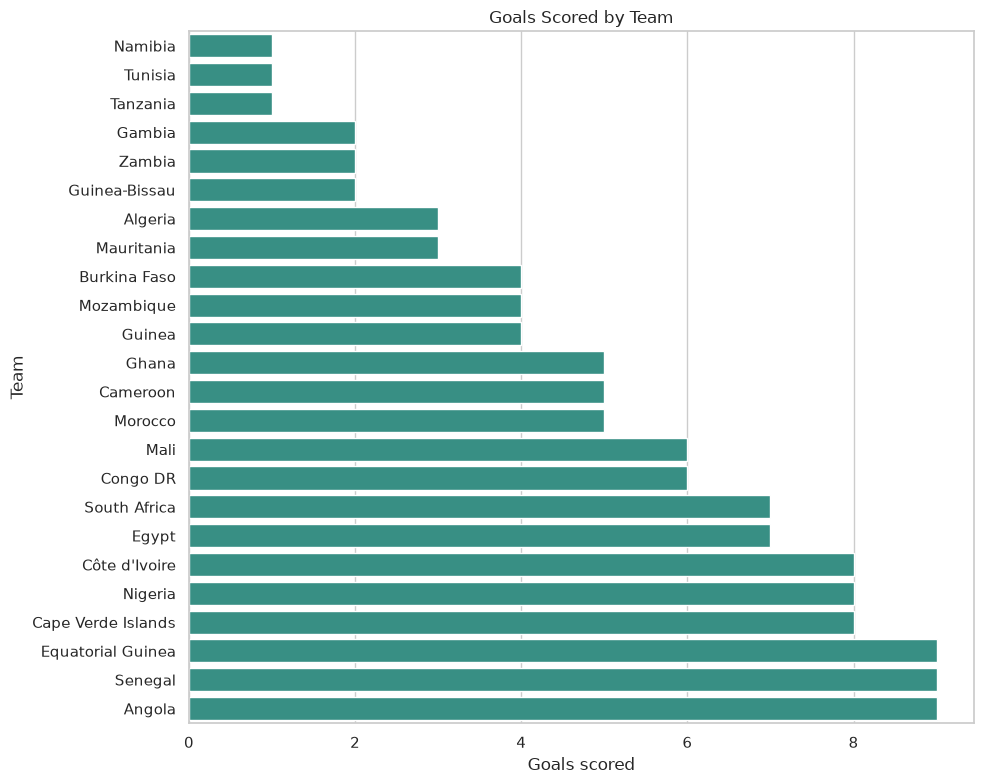

In [18]:
# Compare goals scored by each team
team_goals = team_summary.sort_values('goals_for', ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=team_goals, x='goals_for', y='team', color='#2a9d8f')
plt.title('Goals Scored by Team')
plt.xlabel('Goals scored')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

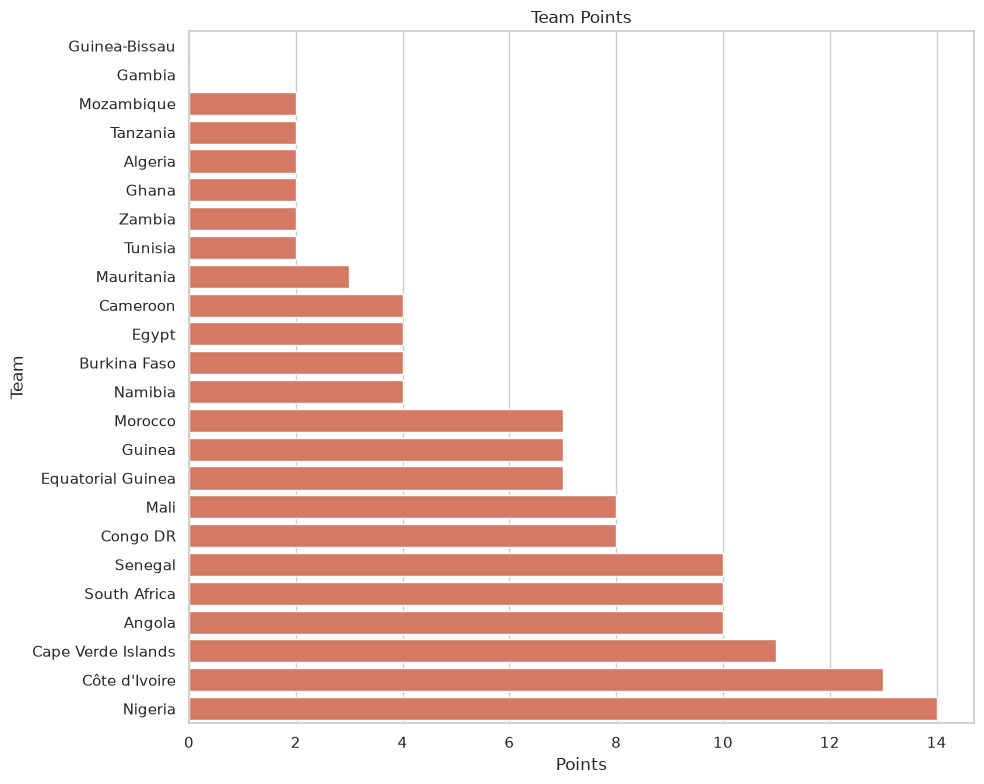

In [19]:
# Compare team points in a standings-style chart
team_points = team_summary.sort_values('points', ascending=True)

plt.figure(figsize=(10, 8))
sns.barplot(data=team_points, x='points', y='team', color='#e76f51')
plt.title('Team Points')
plt.xlabel('Points')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

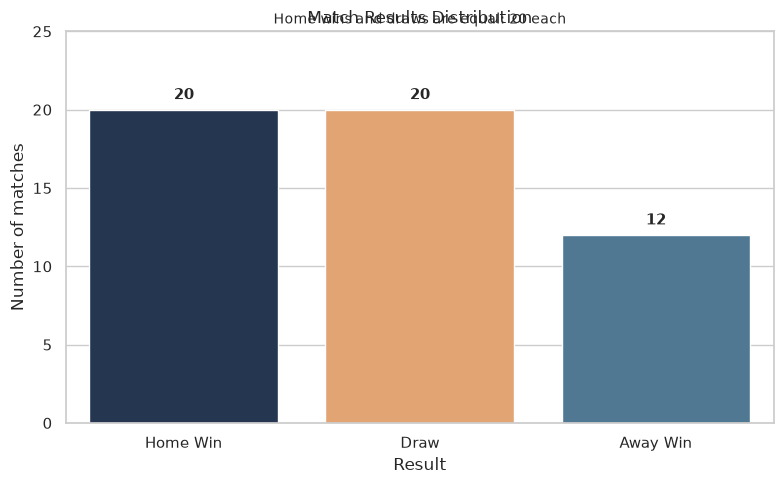

In [23]:
# Display the distribution of match results
result_order = ['Home Win', 'Draw', 'Away Win']
result_colors = {
    'Home Win': '#1d3557',
    'Draw': '#f4a261',
    'Away Win': '#457b9d'
}

plt.figure(figsize=(8, 5))
result_plot = sns.barplot(
    data=result_summary,
    x='result',
    y='matches',
    order=result_order,
    hue='result',
    palette=result_colors,
    legend=False
)

for bar in result_plot.patches:
    result_plot.annotate(
        f'{int(bar.get_height())}',
        (bar.get_x() + bar.get_width() / 2, bar.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

home_wins = result_summary.loc[
    result_summary['result'].eq('Home Win'), 'matches'
].iloc[0]
draws = result_summary.loc[
    result_summary['result'].eq('Draw'), 'matches'
].iloc[0]

plt.title('Match Results Distribution')
plt.text(
    0.5,
    1.02,
    f'Home wins and draws are equal: {home_wins} each',
    transform=result_plot.transAxes,
    ha='center',
    fontsize=10
)
plt.xlabel('Result')
plt.ylabel('Number of matches')
plt.ylim(0, result_summary['matches'].max() + 5)
plt.tight_layout()
plt.show()

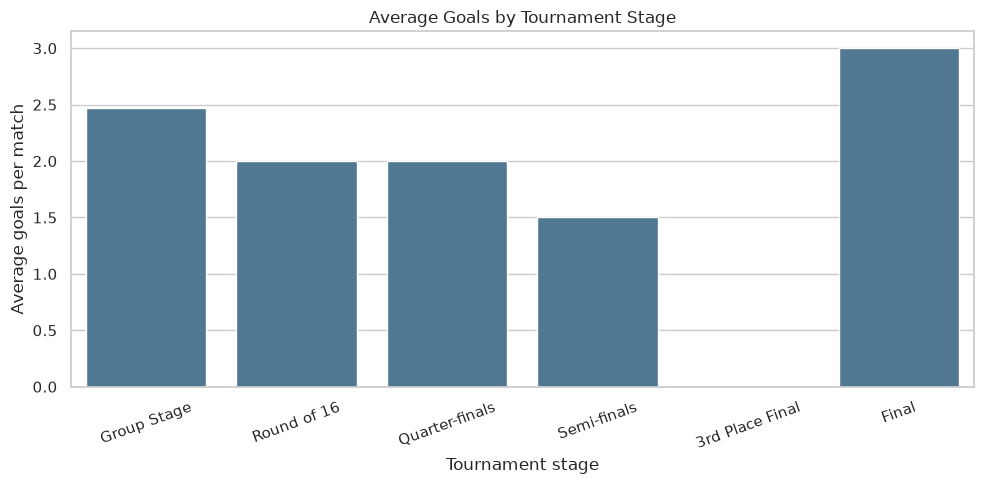

In [21]:
# Compare average goals across tournament stages
stage_order = [
    'Group Stage',
    'Round of 16',
    'Quarter-finals',
    'Semi-finals',
    '3rd Place Final',
    'Final'
]
stage_goals = stage_summary.copy()
stage_goals['competition_stage'] = pd.Categorical(
    stage_goals['competition_stage'],
    categories=stage_order,
    ordered=True
)
stage_goals = stage_goals.sort_values('competition_stage')

plt.figure(figsize=(10, 5))
sns.barplot(
    data=stage_goals,
    x='competition_stage',
    y='average_goals',
    color='#457b9d'
)
plt.title('Average Goals by Tournament Stage')
plt.xlabel('Tournament stage')
plt.ylabel('Average goals per match')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

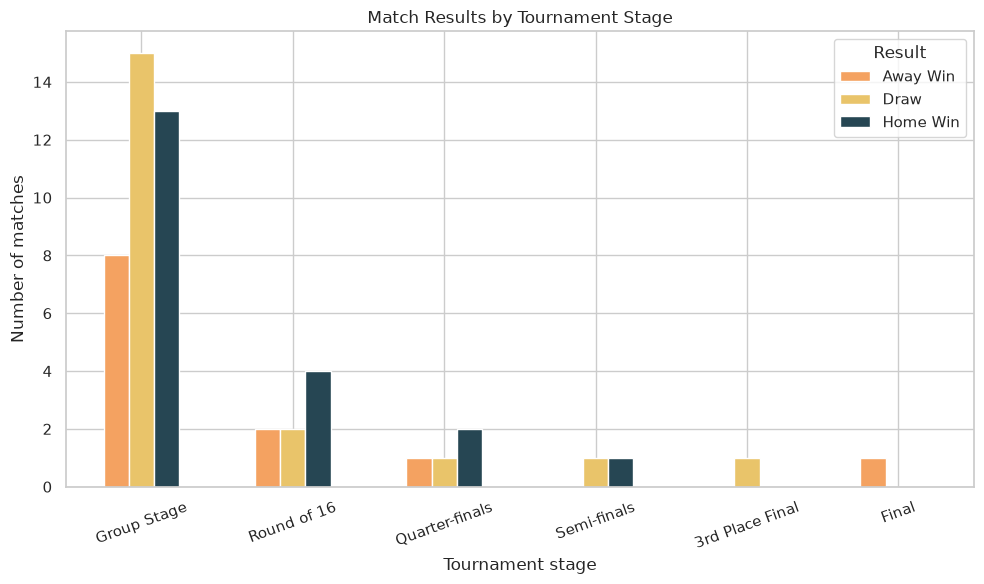

In [22]:
# Show match results across tournament stages
stage_results_plot = stage_results.reindex(stage_order).fillna(0)

stage_results_plot.plot(
    kind='bar',
    figsize=(10, 6),
    color={'Home Win': '#264653', 'Draw': '#e9c46a', 'Away Win': '#f4a261'}
)
plt.title('Match Results by Tournament Stage')
plt.xlabel('Tournament stage')
plt.ylabel('Number of matches')
plt.xticks(rotation=20)
plt.legend(title='Result')
plt.tight_layout()
plt.show()